# Part 1: Online Reserve Pricing

This notebook builds, from scratch, two methods to learn the reserve price in a truthful second-price auction with i.i.d. bidders, and compares them to theory:

- Bandit baseline over a discretized reserve grid
- Myerson plug-in using empirical CDF (pick monopoly reserve r maximizing r·(1−F(r)))

We simulate bidders’ valuations from specified distributions and track revenue convergence to the optimal benchmark. The code is modular and commented for step-by-step understanding.


In [10]:
# Setup: imports and folders
import os
import math
import csv
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt

# Ensure folders exist relative to project root
PROJECT_ROOT = "/Users/ben/Documents/School/2025-2026/Q1/CS332/332Project4_2"
FIG_DIR = os.path.join(PROJECT_ROOT, "figures")
RES_DIR = os.path.join(PROJECT_ROOT, "results")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

# Global plotting style
plt.style.use("seaborn-v0_8-whitegrid")

# Reproducibility
RNG = np.random.default_rng(42)


In [2]:
# Distributions: samplers
# We return samples in [0,1].

def sample_uniform(n: int, rng: np.random.Generator = RNG) -> np.ndarray:
    return rng.random(n)

# Quadratic CDF F(z)=z^2 on [0,1] has inverse F^{-1}(q)=sqrt(q)
# To sample: draw q~U[0,1], return sqrt(q)

def sample_quadratic(n: int, rng: np.random.Generator = RNG) -> np.ndarray:
    return np.sqrt(rng.random(n))

# Registry for convenience
SAMPLERS: Dict[str, Callable[[int], np.ndarray]] = {
    "uniform": lambda n: sample_uniform(n, RNG),
    "quadratic": lambda n: sample_quadratic(n, RNG),
}

list(SAMPLERS.keys())


['uniform', 'quadratic']

In [3]:
# Second-price auction with reserve (single item)

def second_price_with_reserve(bids: np.ndarray, reserve: float) -> float:
    """Compute revenue for one round of a second-price auction with reserve.
    bids: 1D array of bidder valuations (truthful bids), length m
    reserve: reserve price in [0,1]
    """
    if bids.size == 0:
        return 0.0
    max_bid = float(np.max(bids))
    if max_bid < reserve:
        return 0.0
    # winner pays max(reserve, second-highest bid)
    if bids.size == 1:
        return float(reserve)
    # find second highest efficiently
    idx_max = int(np.argmax(bids))
    second_highest = float(np.max(np.delete(bids, idx_max)))
    return float(max(reserve, second_highest))


def run_round(sampler: Callable[[int], np.ndarray], m: int, reserve: float) -> float:
    bids = sampler(m)
    return second_price_with_reserve(bids, reserve)


def simulate(sampler: Callable[[int], np.ndarray], m: int, reserves_over_time: np.ndarray) -> np.ndarray:
    """Simulate a sequence of rounds with possibly changing reserve.
    reserves_over_time: array of length T
    Returns per-round revenue array of length T.
    """
    T = reserves_over_time.size
    revenues = np.empty(T, dtype=float)
    for t in range(T):
        revenues[t] = run_round(sampler, m, float(reserves_over_time[t]))
    return revenues


In [4]:
# Bandit baseline: epsilon-greedy over a reserve grid

@dataclass
class EpsilonGreedyConfig:
    epsilon_c: float = 1.0  # epsilon_t = min(1, c/sqrt(t))
    T: int = 20000          # horizon (adjust as needed)
    grid_size: int = 101    # reserves in [0,1]


class EpsilonGreedyBandit:
    def __init__(self, grid_size: int, epsilon_c: float = 1.0):
        self.grid = np.linspace(0.0, 1.0, grid_size)
        self.num_arms = grid_size
        self.counts = np.zeros(self.num_arms, dtype=int)
        self.means = np.zeros(self.num_arms, dtype=float)
        self.epsilon_c = epsilon_c
        self.t = 0

    def _epsilon(self) -> float:
        if self.t <= 0:
            return 1.0
        return min(1.0, self.epsilon_c / math.sqrt(self.t))

    def select_arm(self) -> int:
        self.t += 1
        eps = self._epsilon()
        if RNG.random() < eps:
            return int(RNG.integers(self.num_arms))
        return int(np.argmax(self.means))

    def update(self, arm: int, reward: float) -> None:
        self.counts[arm] += 1
        n = self.counts[arm]
        # incremental mean update
        self.means[arm] += (reward - self.means[arm]) / n


def run_bandit(sampler: Callable[[int], np.ndarray], m: int, cfg: EpsilonGreedyConfig) -> Dict[str, np.ndarray]:
    bandit = EpsilonGreedyBandit(grid_size=cfg.grid_size, epsilon_c=cfg.epsilon_c)
    T = cfg.T
    chosen_arms = np.empty(T, dtype=int)
    chosen_reserves = np.empty(T, dtype=float)
    rewards = np.empty(T, dtype=float)

    for t in range(T):
        arm = bandit.select_arm()
        r = float(bandit.grid[arm])
        reward = run_round(sampler, m, r)
        bandit.update(arm, reward)

        chosen_arms[t] = arm
        chosen_reserves[t] = r
        rewards[t] = reward

    return {
        "grid": bandit.grid,
        "chosen_arms": chosen_arms,
        "chosen_reserves": chosen_reserves,
        "rewards": rewards,
        "final_means": bandit.means,
        "counts": bandit.counts,
    }


In [5]:
# Myerson plug-in: empirical CDF to choose monopoly reserve

class EmpiricalCDF:
    def __init__(self):
        self.values = np.empty(0, dtype=float)

    def update_with(self, new_values: np.ndarray) -> None:
        if new_values.size == 0:
            return
        if self.values.size == 0:
            self.values = np.sort(new_values.astype(float))
        else:
            self.values = np.sort(np.concatenate([self.values, new_values.astype(float)]))

    def F_hat(self, z: float) -> float:
        if self.values.size == 0:
            return 0.0
        # fraction of samples <= z
        return float(np.searchsorted(self.values, z, side="right") / self.values.size)


def choose_reserve_from_ecdf(ecdf: EmpiricalCDF, grid: np.ndarray) -> float:
    if ecdf.values.size == 0:
        return float(grid[0])
    # maximize z * (1 - F_hat(z)) over grid
    vals = np.array([z * (1.0 - ecdf.F_hat(float(z))) for z in grid], dtype=float)
    best_idx = int(np.argmax(vals))
    return float(grid[best_idx])


@dataclass
class PluginConfig:
    T: int = 20000
    grid_size: int = 1001  # finer grid for r*(1-F(r)) argmax
    update_every: int = 1   # set >1 to update less frequently for speed


def run_plugin(sampler: Callable[[int], np.ndarray], m: int, cfg: PluginConfig) -> Dict[str, np.ndarray]:
    ecdf = EmpiricalCDF()
    grid = np.linspace(0.0, 1.0, cfg.grid_size)
    T = cfg.T
    reserves = np.empty(T, dtype=float)
    rewards = np.empty(T, dtype=float)

    r_t = 0.0
    for t in range(T):
        # choose reserve
        if t % cfg.update_every == 0:
            r_t = choose_reserve_from_ecdf(ecdf, grid)
        reserves[t] = r_t

        # run round and observe all bids (for learning F)
        bids = sampler(m)
        rewards[t] = second_price_with_reserve(bids, r_t)
        ecdf.update_with(bids)

    return {
        "grid": grid,
        "chosen_reserves": reserves,
        "rewards": rewards,
        "num_samples": ecdf.values.size,
    }


In [6]:
# Baselines: approximate optimal reserve and expected revenue via Monte Carlo

@dataclass
class BaselineConfig:
    grid_size: int = 1001
    rounds: int = 200_000  # total Monte Carlo rounds per (m, reserve)


def estimate_expected_revenue(sampler: Callable[[int], np.ndarray], m: int, reserve: float, rounds: int) -> float:
    revenues = np.empty(rounds, dtype=float)
    for t in range(rounds):
        bids = sampler(m)
        revenues[t] = second_price_with_reserve(bids, reserve)
    return float(np.mean(revenues))


def estimate_optimal(sampler: Callable[[int], np.ndarray], m: int, cfg: BaselineConfig) -> Dict[str, float]:
    grid = np.linspace(0.0, 1.0, cfg.grid_size)
    est_revs = np.empty(cfg.grid_size, dtype=float)
    for i, r in enumerate(grid):
        est_revs[i] = estimate_expected_revenue(sampler, m, float(r), cfg.rounds)
    best_idx = int(np.argmax(est_revs))
    return {
        "best_reserve": float(grid[best_idx]),
        "best_revenue": float(est_revs[best_idx]),
    }

# Known analytic check for U[0,1] with m=2: optimal reserve=0.5, optimal expected revenue=5/12≈0.4167


In [7]:
# Experiments: run learners across distributions and bidder counts

EXPERIMENT_SETTINGS = {
    "distributions": ["uniform", "quadratic"],
    "m_list": [2, 5, 10],
    "T": 20000,
    "bandit_grid": 101,
    "plugin_grid": 1001,
}


def run_all_experiments() -> Dict[str, dict]:
    results = {}
    for dist_name in EXPERIMENT_SETTINGS["distributions"]:
        sampler = SAMPLERS[dist_name]
        results[dist_name] = {}
        for m in EXPERIMENT_SETTINGS["m_list"]:
            # Bandit
            bandit_cfg = EpsilonGreedyConfig(
                epsilon_c=1.0,
                T=EXPERIMENT_SETTINGS["T"],
                grid_size=EXPERIMENT_SETTINGS["bandit_grid"],
            )
            bandit_out = run_bandit(sampler, m, bandit_cfg)

            # Plugin
            plugin_cfg = PluginConfig(
                T=EXPERIMENT_SETTINGS["T"],
                grid_size=EXPERIMENT_SETTINGS["plugin_grid"],
                update_every=1,
            )
            plugin_out = run_plugin(sampler, m, plugin_cfg)

            # Baseline
            baseline_cfg = BaselineConfig(grid_size=EXPERIMENT_SETTINGS["plugin_grid"], rounds=50_000)
            baseline = estimate_optimal(sampler, m, baseline_cfg)

            results[dist_name][m] = {
                "bandit": bandit_out,
                "plugin": plugin_out,
                "baseline": baseline,
            }
    return results

# Example: to run (can be time-consuming). Keep T smaller first if needed.
RESULTS = run_all_experiments()
list(RESULTS.keys())


['uniform', 'quadratic']

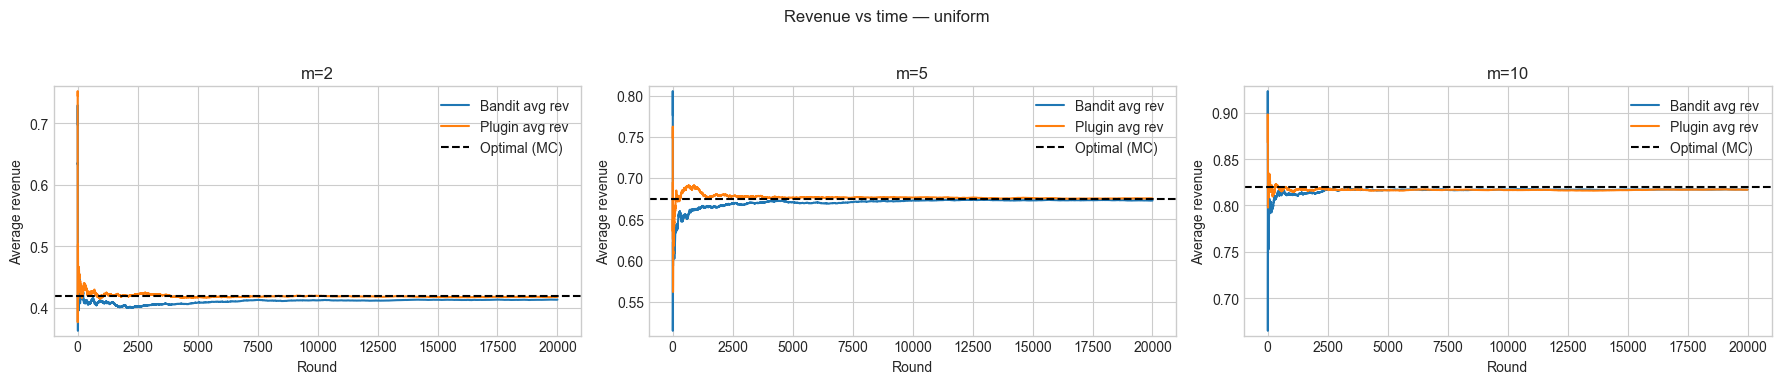

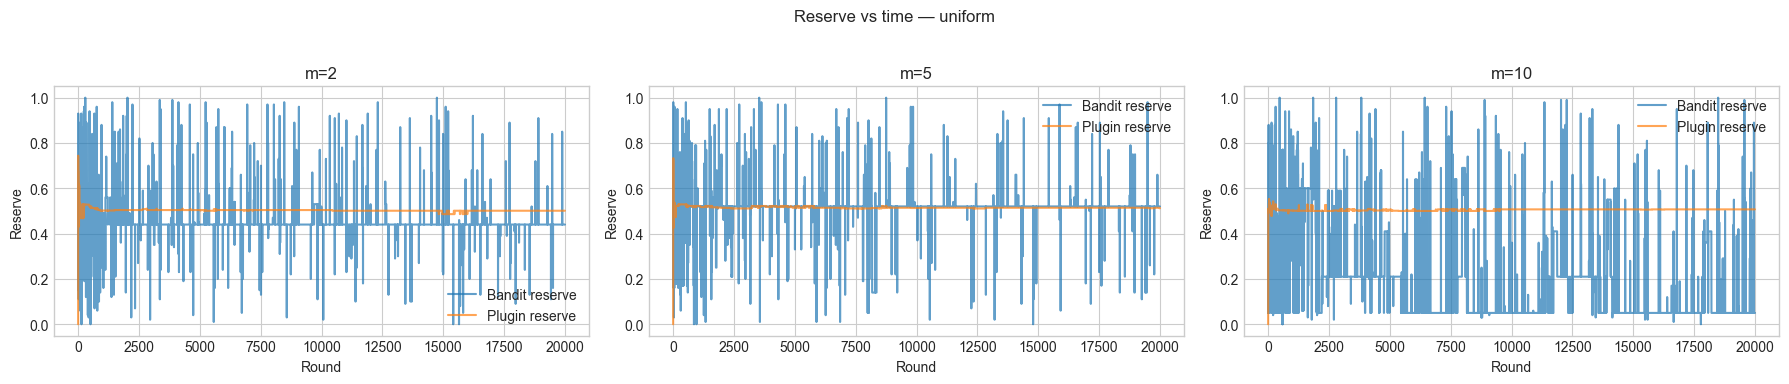

In [14]:
# Plotting helpers

def plot_revenue_curves(results: dict, title: str, save_path: Optional[str] = None, tight: bool = True, pad: float = 0.02, ymin: Optional[float] = None, ymax: Optional[float] = None) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    m_values = sorted(results.keys())
    for ax, m in zip(axes, m_values):
        bandit_rewards = results[m]["bandit"]["rewards"]
        plugin_rewards = results[m]["plugin"]["rewards"]
        baseline_rev = results[m]["baseline"]["best_revenue"]

        avg_b = np.cumsum(bandit_rewards) / (np.arange(bandit_rewards.size) + 1)
        avg_p = np.cumsum(plugin_rewards) / (np.arange(plugin_rewards.size) + 1)
        ax.plot(avg_b, label="Bandit avg rev")
        ax.plot(avg_p, label="Plugin avg rev")
        ax.axhline(baseline_rev, color="black", linestyle="--", label="Optimal (MC)")
        ax.set_title(f"m={m}")
        ax.set_xlabel("Round")
        ax.set_ylabel("Average revenue")

        # Auto-zoom around the main lines
        if tight:
            vals = np.r_[avg_b, avg_p, baseline_rev]
            y_lo = float(np.min(vals))
            y_hi = float(np.max(vals))
            span = max(y_hi - y_lo, 1e-6)
            y_lo -= pad * span
            y_hi += pad * span
            if ymin is not None:
                y_lo = ymin
            if ymax is not None:
                y_hi = ymax
            ax.set_ylim(y_lo, y_hi)

        ax.legend()

    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    if save_path is not None:
        fig.savefig(save_path, dpi=150)
    plt.show()


def plot_reserve_trajectories(results: dict, title: str, save_path: Optional[str] = None) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    m_values = sorted(results.keys())
    for ax, m in zip(axes, m_values):
        bandit_r = results[m]["bandit"]["chosen_reserves"]
        plugin_r = results[m]["plugin"]["chosen_reserves"]
        ax.plot(bandit_r, alpha=0.7, label="Bandit reserve")
        ax.plot(plugin_r, alpha=0.7, label="Plugin reserve")
        ax.set_title(f"m={m}")
        ax.set_xlabel("Round")
        ax.set_ylabel("Reserve")
        ax.legend()

    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    if save_path is not None:
        fig.savefig(save_path, dpi=150)
    plt.show()


# Example usage after running experiments for a distribution:
dist_name = "uniform"
plot_revenue_curves(RESULTS[dist_name], title=f"Revenue vs time — {dist_name}", save_path=os.path.join(FIG_DIR, f"rev_{dist_name}.png"))
plot_reserve_trajectories(RESULTS[dist_name], title=f"Reserve vs time — {dist_name}", save_path=os.path.join(FIG_DIR, f"res_{dist_name}.png"))


In [12]:
# Export: save key metrics to CSV

def export_summary(results: dict, csv_path: str) -> None:
    fields = [
        "distribution", "m", 
        "bandit_final_avg_rev", "plugin_final_avg_rev", 
        "baseline_best_reserve", "baseline_best_revenue",
    ]
    with open(csv_path, mode="w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        for dist_name, per_m in results.items():
            for m, out in per_m.items():
                b_rewards = out["bandit"]["rewards"]
                p_rewards = out["plugin"]["rewards"]
                row = {
                    "distribution": dist_name,
                    "m": m,
                    "bandit_final_avg_rev": float(np.mean(b_rewards)),
                    "plugin_final_avg_rev": float(np.mean(p_rewards)),
                    "baseline_best_reserve": float(out["baseline"]["best_reserve"]),
                    "baseline_best_revenue": float(out["baseline"]["best_revenue"]),
                }
                writer.writerow(row)

# Example after running:
export_summary(RESULTS, os.path.join(RES_DIR, "summary.csv"))


In [ ]:
# EXTENSION: multi-unit auction (k items, (k+1)th price) with reserve

def k_unit_price_with_reserve(bids: np.ndarray, reserve: float, k: int) -> float:
    """Revenue for k-unit auction with (k+1)th price rule and reserve.
    If fewer than k bids >= reserve, sell only those meeting reserve.
    Price per sold unit = max(reserve, (k+1)th highest bid among all bids).
    If fewer than k+1 bids, treat (k+1)th as 0 for pricing floor with reserve.
    """
    if bids.size == 0 or k <= 0:
        return 0.0
    sorted_bids = np.sort(bids)[::-1]  # descending
    winners_mask = sorted_bids >= reserve
    num_eligible = int(np.sum(winners_mask))
    num_sold = min(k, num_eligible)
    if num_sold == 0:
        return 0.0
    kth_plus_one_idx = k  # 0-based index
    kth_plus_one = float(sorted_bids[kth_plus_one_idx]) if kth_plus_one_idx < sorted_bids.size else 0.0
    unit_price = float(max(reserve, kth_plus_one))
    return float(num_sold * unit_price)


def run_round_k_unit(sampler: Callable[[int], np.ndarray], m: int, reserve: float, k: int) -> float:
    bids = sampler(m)
    return k_unit_price_with_reserve(bids, reserve, k)

# You can analogously build a simulator and plug this into bandit/plugin if exploring multi-unit settings.


In [18]:
# Seeded samplers and multi-seed utilities

def get_sampler(dist_name: str, seed: int) -> Callable[[int], np.ndarray]:
    rng = np.random.default_rng(seed)
    if dist_name == "uniform":
        return lambda n: rng.random(n)
    if dist_name == "quadratic":
        return lambda n: np.sqrt(rng.random(n))
    raise ValueError(f"Unknown distribution: {dist_name}")


def run_all_experiments_multiseed(dist_name: str, m_list: List[int], T: int, seeds: List[int], bandit_grid: int = 101, plugin_grid: int = 1001) -> Dict[int, Dict[str, Dict[str, np.ndarray]]]:
    """Returns nested dict: results[m]['bandit'|'plugin'][seed_key] -> dict with rewards/reserves.
    """
    out: Dict[int, Dict[str, Dict[str, dict]]] = {}
    for m in m_list:
        out[m] = {"bandit": {}, "plugin": {}}
        for s in seeds:
            sampler = get_sampler(dist_name, s)

            bandit_cfg = EpsilonGreedyConfig(epsilon_c=1.0, T=T, grid_size=bandit_grid)
            bandit = run_bandit(sampler, m, bandit_cfg)
            out[m]["bandit"][s] = bandit

            plugin_cfg = PluginConfig(T=T, grid_size=plugin_grid, update_every=1)
            plugin = run_plugin(sampler, m, plugin_cfg)
            out[m]["plugin"][s] = plugin
    return out


def mc_baseline_for_dist(dist_name: str, m: int, grid_size: int = 1001, rounds: int = 50000, seed: int = 12345) -> Dict[str, float]:
    sampler = get_sampler(dist_name, seed)
    cfg = BaselineConfig(grid_size=grid_size, rounds=rounds)
    return estimate_optimal(sampler, m, cfg)


def compute_ci_curves(values: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """values shape: (num_seeds, T). Returns mean, lo, hi (95% CI)."""
    means = values.mean(axis=0)
    stds = values.std(axis=0, ddof=1) if values.shape[0] > 1 else np.zeros_like(means)
    cis = 1.96 * stds / np.sqrt(max(1, values.shape[0]))
    return means, means - cis, means + cis


def plot_with_ci(ax: plt.Axes, y_values: np.ndarray, label: str, color: Optional[str] = None):
    mean, lo, hi = compute_ci_curves(y_values)
    x = np.arange(y_values.shape[1])
    line, = ax.plot(x, mean, label=label, color=color)
    ax.fill_between(x, lo, hi, color=line.get_color() if color is None else color, alpha=0.15)
    return line


In [19]:
# CI/regret plotting for one distribution

def plot_ci_and_regret_for_dist(dist_name: str, T: int = 20000, seeds: List[int] = [1,2,3], m_list: List[int] = [2,5,10]) -> None:
    all_results = run_all_experiments_multiseed(dist_name, m_list, T, seeds)

    # For each m, build arrays: seeds x T for avg revenue and per-round regret
    fig1, axes1 = plt.subplots(1, len(m_list), figsize=(6 * len(m_list), 4))
    fig2, axes2 = plt.subplots(1, len(m_list), figsize=(6 * len(m_list), 4))
    if len(m_list) == 1:
        axes1 = [axes1]
        axes2 = [axes2]

    for ax_rev, ax_reg, m in zip(axes1, axes2, m_list):
        # Baseline (MC optimal) revenue
        baseline = mc_baseline_for_dist(dist_name, m)
        opt_rev = baseline["best_revenue"]

        # Bandit
        b_rewards = np.stack([all_results[m]["bandit"][s]["rewards"] for s in seeds])
        b_avg = np.cumsum(b_rewards, axis=1) / (np.arange(T) + 1)
        plot_with_ci(ax_rev, b_avg, label="Bandit avg rev")
        b_regret = opt_rev - b_rewards
        b_cum_regret = np.cumsum(b_regret, axis=1)
        plot_with_ci(ax_reg, b_cum_regret, label="Bandit cum regret")

        # Plugin
        p_rewards = np.stack([all_results[m]["plugin"][s]["rewards"] for s in seeds])
        p_avg = np.cumsum(p_rewards, axis=1) / (np.arange(T) + 1)
        plot_with_ci(ax_rev, p_avg, label="Plugin avg rev")
        p_regret = opt_rev - p_rewards
        p_cum_regret = np.cumsum(p_regret, axis=1)
        plot_with_ci(ax_reg, p_cum_regret, label="Plugin cum regret")

        # Targets and labels
        ax_rev.axhline(opt_rev, color="black", linestyle="--", label="Optimal (MC)")
        ax_rev.set_title(f"{dist_name}, m={m}")
        ax_rev.set_xlabel("Round")
        ax_rev.set_ylabel("Average revenue")
        ax_rev.legend()

        ax_reg.set_title(f"{dist_name}, m={m}")
        ax_reg.set_xlabel("Round")
        ax_reg.set_ylabel("Cumulative regret")
        ax_reg.legend()

    fig1.suptitle(f"Average revenue with 95% CI — {dist_name}")
    fig1.tight_layout()
    fig2.suptitle(f"Cumulative regret with 95% CI — {dist_name}")
    fig2.tight_layout()

    # Save
    fig1.savefig(os.path.join(FIG_DIR, f"rev_{dist_name}_ci.png"), dpi=150)
    fig2.savefig(os.path.join(FIG_DIR, f"regret_{dist_name}_ci.png"), dpi=150)
    plt.show()


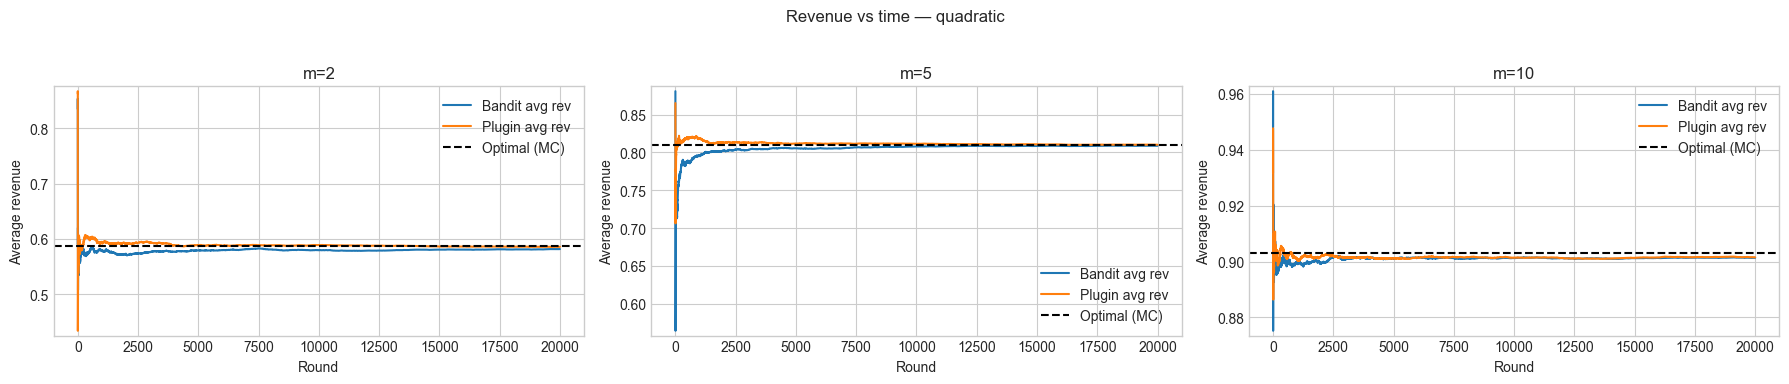

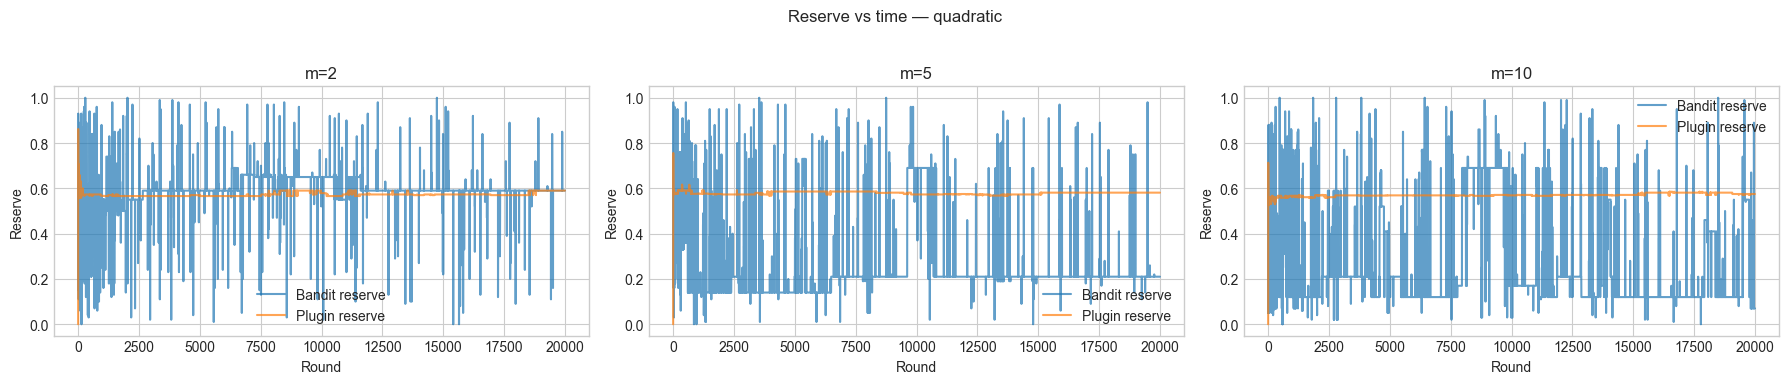

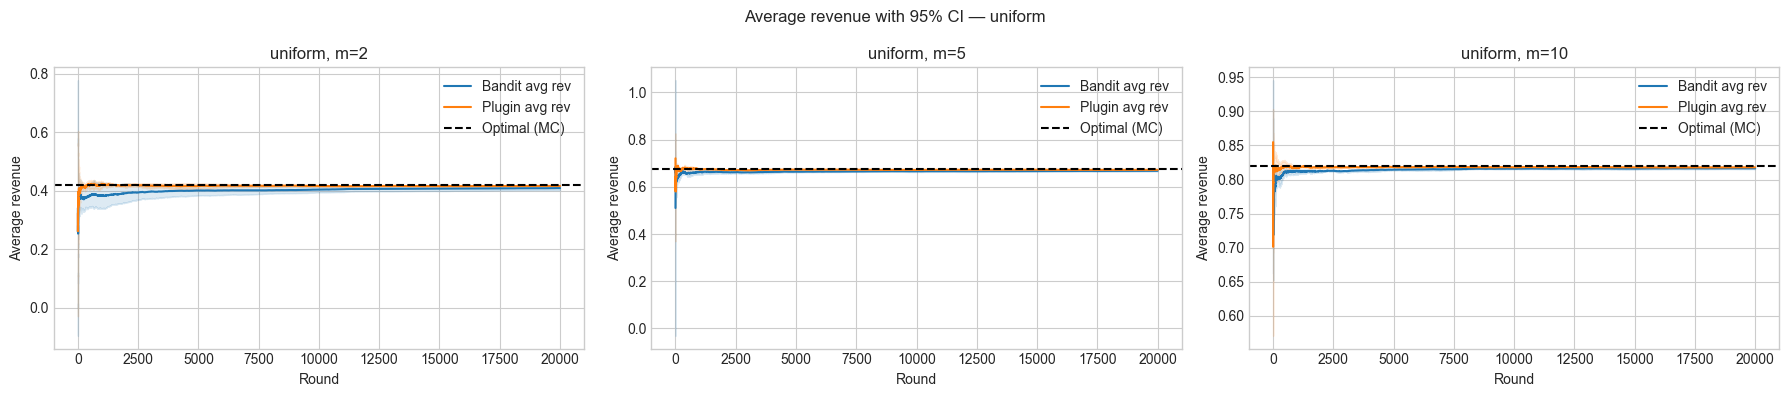

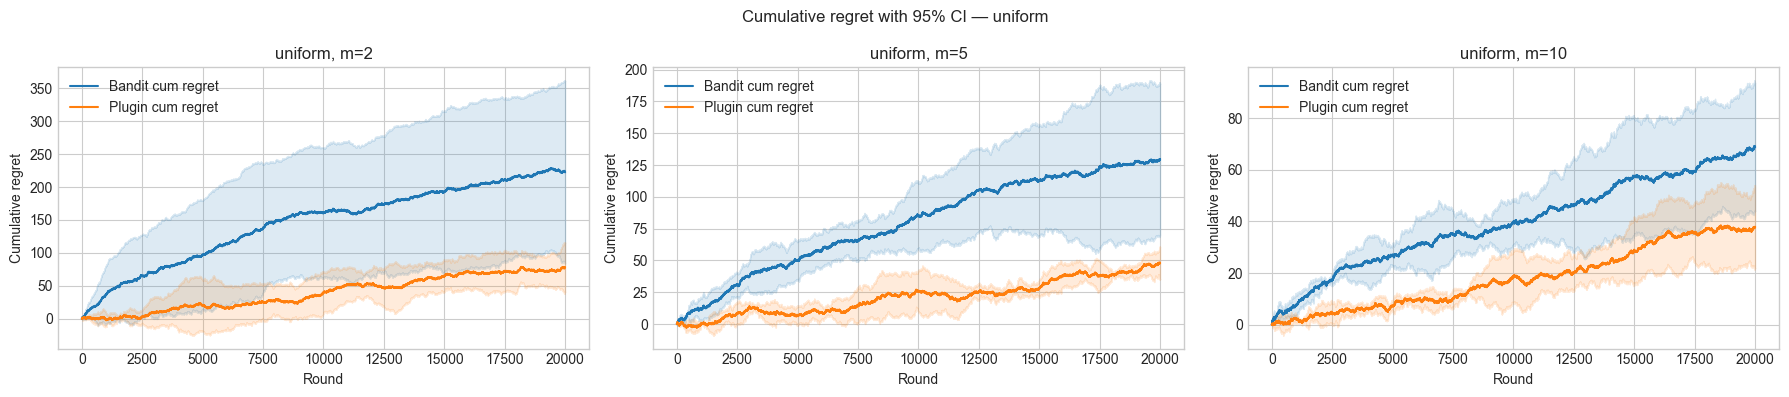

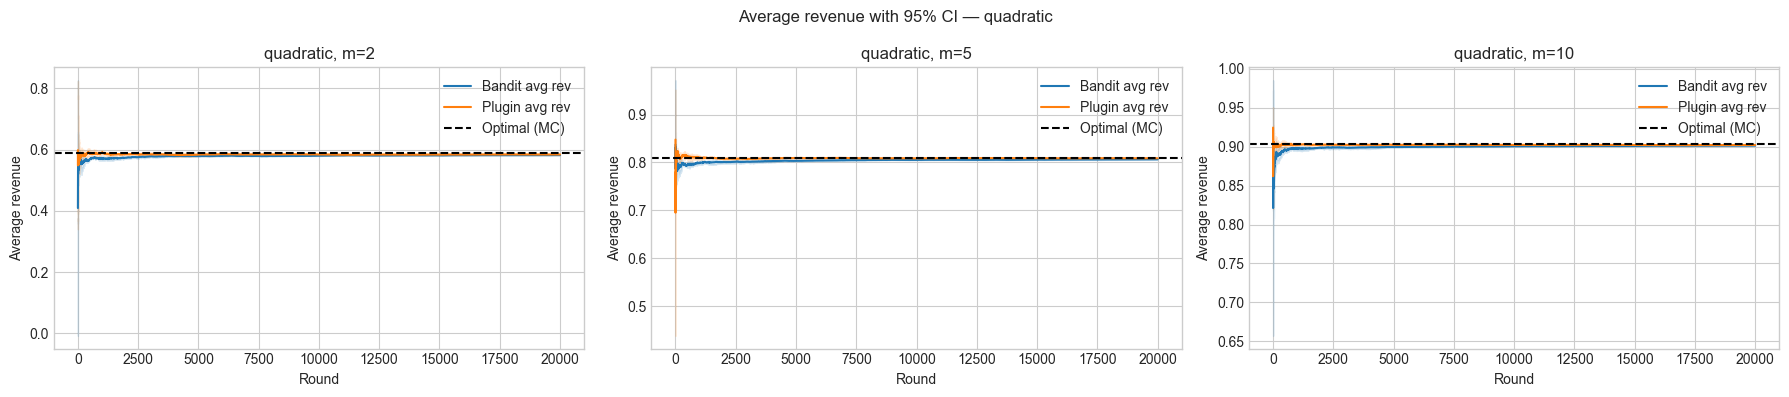

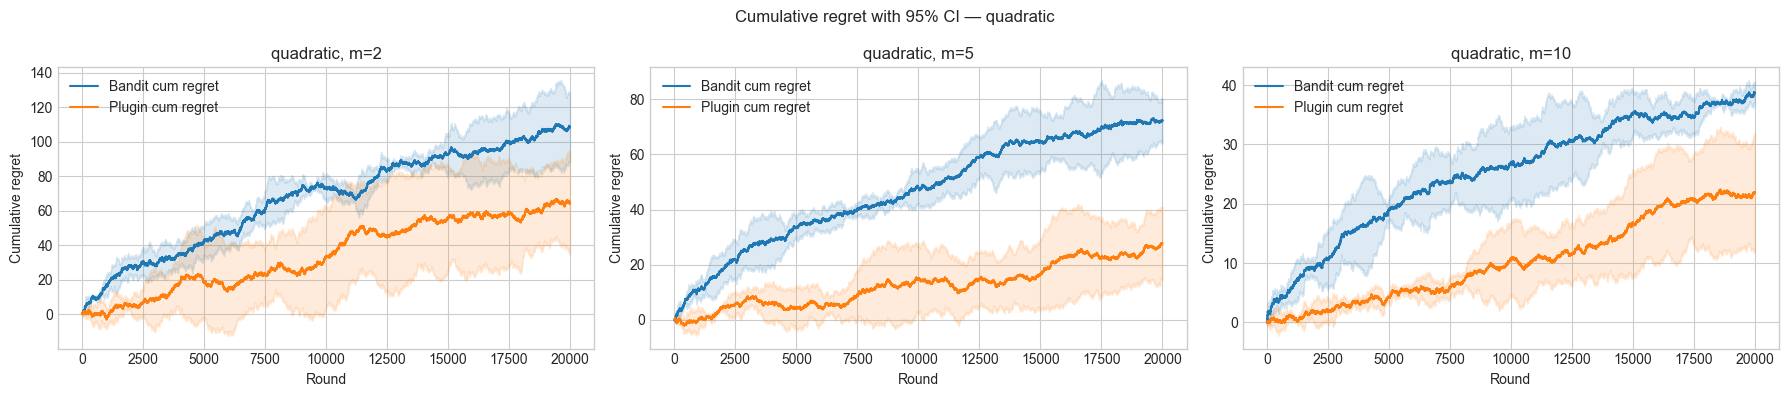

In [20]:
# Batch generation cell for figures and tables
# Run this cell to produce: rev_quadratic.png, res_quadratic.png, CI/regret plots for uniform & quadratic.

# 1) Quadratic single-seed figures (reuse existing helpers)
EXP_SETTINGS_BACKUP = EXPERIMENT_SETTINGS.copy()
EXP_SETTINGS_QUAD = {
    "distributions": ["quadratic"],
    "m_list": EXPERIMENT_SETTINGS["m_list"],
    "T": EXPERIMENT_SETTINGS["T"],
    "bandit_grid": EXPERIMENT_SETTINGS["bandit_grid"],
    "plugin_grid": EXPERIMENT_SETTINGS["plugin_grid"],
}
EXPERIMENT_SETTINGS = EXP_SETTINGS_QUAD
RESULTS_QUAD = run_all_experiments()
plot_revenue_curves(RESULTS_QUAD["quadratic"], title="Revenue vs time — quadratic", save_path=os.path.join(FIG_DIR, "rev_quadratic.png"))
plot_reserve_trajectories(RESULTS_QUAD["quadratic"], title="Reserve vs time — quadratic", save_path=os.path.join(FIG_DIR, "res_quadratic.png"))
# restore
EXPERIMENT_SETTINGS = EXP_SETTINGS_BACKUP

# 2) CI and regret plots for uniform and quadratic
plot_ci_and_regret_for_dist("uniform", T=EXPERIMENT_SETTINGS["T"], seeds=[1,2,3], m_list=EXPERIMENT_SETTINGS["m_list"])
plot_ci_and_regret_for_dist("quadratic", T=EXPERIMENT_SETTINGS["T"], seeds=[1,2,3], m_list=EXPERIMENT_SETTINGS["m_list"])


In [29]:
# Multi-unit quick demo (k items, (k+1)-st price) — figure generator

def simulate_k_unit(sampler: Callable[[int], np.ndarray], m: int, reserves_over_time: np.ndarray, k: int) -> np.ndarray:
    T = reserves_over_time.size
    revenues = np.empty(T, dtype=float)
    for t in range(T):
        bids = sampler(m)
        revenues[t] = k_unit_price_with_reserve(bids, float(reserves_over_time[t]), k)
    return revenues


def run_k_unit_plugin(
    dist_name: str,
    m: int,
    k: int,
    T: int = 20000,
    grid_size: int = 801,
    seeds: List[int] = [1, 2, 3],
    show_baseline: bool = True,
    tight: bool = True,
    pad: float = 0.02,
    ymin: Optional[float] = None,
    ymax: Optional[float] = None,
) -> None:
    # Plug-in learner for k-unit case: choose reserve via r*(1-F_hat(r)); compute per-seed reward series of length T
    grid = np.linspace(0.0, 1.0, grid_size)
    per_seed_rewards: List[np.ndarray] = []
    for s in seeds:
        sampler = get_sampler(dist_name, s)
        ecdf = EmpiricalCDF()
        rewards = np.empty(T, dtype=float)
        r_t = 0.0
        for t in range(T):
            r_t = choose_reserve_from_ecdf(ecdf, grid) if (t % 1 == 0) else r_t
            bids = sampler(m)
            rewards[t] = k_unit_price_with_reserve(bids, r_t, k)
            ecdf.update_with(bids)
        per_seed_rewards.append(rewards)

    # Stack and plot CI across seeds (shape: num_seeds x T)
    R = np.stack(per_seed_rewards)
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    avg = np.cumsum(R, axis=1) / (np.arange(T) + 1)
    plot_with_ci(ax, avg, label=f"Plugin avg rev (k={k})")

    baseline_rev = None
    if show_baseline:
        baseline = mc_baseline_k_unit(dist_name, m, k, grid_size=grid_size, rounds=50000)
        baseline_rev = baseline["best_revenue"]
        ax.axhline(baseline_rev, color="black", linestyle="--", label="Optimal (MC)")

    ax.set_title(f"Multi-unit (k={k}) — {dist_name}, m={m}")
    ax.set_xlabel("Round")
    ax.set_ylabel("Average revenue")

    # Auto-tighten y-limits around curves (and baseline if present)
    if tight:
        mean, lo, hi = compute_ci_curves(avg)  # avg is seeds x T
        vals = np.r_[lo, hi]
        if baseline_rev is not None:
            vals = np.r_[vals, baseline_rev]
        y_lo = float(np.min(vals))
        y_hi = float(np.max(vals))
        span = max(y_hi - y_lo, 1e-6)
        y_lo -= pad * span
        y_hi += pad * span
        if ymin is not None:
            y_lo = ymin
        if ymax is not None:
            y_hi = ymax
        ax.set_ylim(y_lo, y_hi)

    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"rev_{dist_name}_k{k}.png"), dpi=150)
    plt.show()

    # MC baseline for multi-unit (k items)

def mc_baseline_k_unit(dist_name: str, m: int, k: int, grid_size: int = 801, rounds: int = 50000, seed: int = 12345) -> Dict[str, float]:
    sampler = get_sampler(dist_name, seed)
    grid = np.linspace(0.0, 1.0, grid_size)
    best_rev = -1.0
    best_r = 0.0
    for r in grid:
        revs = np.empty(rounds, dtype=float)
        for t in range(rounds):
            bids = sampler(m)
            revs[t] = k_unit_price_with_reserve(bids, float(r), k)
        mean_rev = float(np.mean(revs))
        if mean_rev > best_rev:
            best_rev = mean_rev
            best_r = float(r)
    return {"best_reserve": best_r, "best_revenue": best_rev}



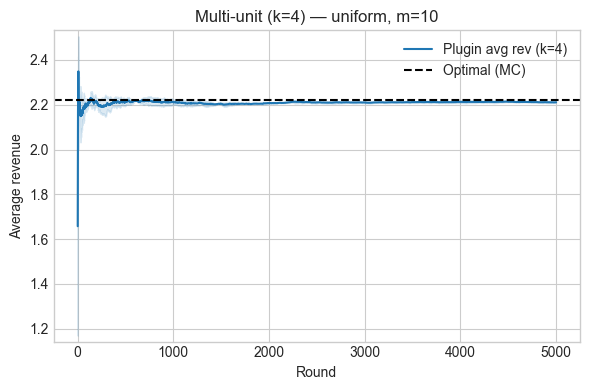

In [30]:
# Run multi-unit demo (optional) — saves to figures
# Example: Uniform, m=10, k=4
run_k_unit_plugin("uniform", m=10, k=4, T=5000, seeds=[1,2,3])
